<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_04.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_04.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 04:** Implementation and Performance Evaluation of Supervised Machine Learning Algorithms (Decision Tree, k-Nearest Neighbors, Naive Bayes, and Support Vector Machine)

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will train four supervised classifiers — **Decision Tree**, **k-Nearest Neighbors (KNN)**, **Naive Bayes**, and **Support Vector Machine (SVM)** — on the same benchmark dataset, compare their performance using multiple metrics, and visualize confusion matrices and ROC curves to interpret the strengths and weaknesses of each model.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Train four supervised classifiers on the same benchmark dataset using a consistent train/test split.
- Compute and compare classification metrics (accuracy, precision, recall, F1-score, ROC-AUC) across multiple algorithms.
- Visualize confusion matrices and ROC curves for model comparison.
- Interpret the strengths and weaknesses of decision trees, KNN, Naive Bayes, and SVM.


## **Theory**

### Introduction

Supervised learning maps input features to known labels using labeled examples. The model learns from training data and then generalizes to unseen samples. Decision trees split the feature space into interpretable regions. k-nearest neighbors classifies a sample by the labels of nearby training examples. Naive Bayes applies probabilistic reasoning under a conditional independence assumption. Support Vector Machines search for a boundary that maximizes the margin between classes.

### Mathematical Background

For a classifier $f(x)$ and labeled sample $(x_i, y_i)$, the training objective is to minimize classification error on the training set and, ideally, on unseen data.

In Naive Bayes, the class posterior is

$$P(y \mid x) \propto P(y) \prod_j P(x_j \mid y)$$

In SVM, the separating hyperplane is $w^T x + b = 0$, and the margin is maximized by minimizing $\|w\|^2$ subject to correct classification constraints.

Decision trees minimize impurity measures such as Gini index or entropy at each split.

### **Model Evaluation Metrics**

After training a machine learning model, its performance must be evaluated using appropriate metrics. Common evaluation metrics for classification include:

- **Accuracy:** Overall proportion of correctly classified samples.
- **Precision:** Percentage of predicted positive samples that are actually positive.
- **Recall (Sensitivity):** Percentage of actual positive samples correctly identified.
- **F1-Score:** Harmonic mean of precision and recall.
- **Confusion Matrix:** Summarizes correct and incorrect predictions.
- **ROC Curve:** Plots the True Positive Rate against the False Positive Rate.
- **AUC (Area Under the Curve):** Measures the classifier's ability to distinguish between classes.

These metrics provide a comprehensive understanding of model performance and help compare different machine learning algorithms.

### Applications

These methods are used in medical diagnosis, document classification, intrusion detection, and many other applied AI systems.

```mermaid
flowchart LR
    A[Labeled Data] --> B[Train/Test Split]
    B --> C[Decision Tree]
    B --> D[KNN]
    B --> E[Naive Bayes]
    B --> F[SVM]
    C --> G[Metrics]
    D --> G
    E --> G
    F --> G
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- Scikit-learn

### Starter Check

This experiment does not include a dedicated print-based setup message. Run the first code cell (library imports). If it completes without errors, your environment is ready.

## **Dataset Description**

This experiment uses the **Breast Cancer Wisconsin dataset**, a standard binary classification benchmark that is readily available in Scikit-learn. It is compact, well studied, and useful for comparing algorithms under the same experimental conditions.

- **Features:** 30 numeric measurements computed from breast mass images.
- **Target labels:** malignant and benign.
- **Source:** `sklearn.datasets.load_breast_cancer`.
- **Reason for selection:** a realistic binary classification problem with enough features to show differences between models.

## **Experimental Procedure**

Follow the steps below in order:

1. Load the dataset and inspect feature names, class distribution, and data shape.
2. Split the data into train and test partitions using a fixed random seed.
3. Scale the features for KNN and SVM (using a pipeline).
4. Train Decision Tree, KNN, Naive Bayes, and SVM classifiers.
5. Compute accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.
6. Plot confusion matrices and ROC curves to compare the models visually.
7. Compare the results and discuss the best model for the dataset.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Which model achieved the highest accuracy and ROC-AUC on this split?
- Which model produced the most false negatives, and why might that matter in a medical context?
- Why do KNN and SVM use a `StandardScaler` inside a pipeline, but the Decision Tree and Naive Bayes do not?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try changing the `test_size`, the number of neighbors in KNN, or the SVM kernel, and observe what changes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

# Load Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

print("Wine dataset loaded successfully!")
print("Dataset shape:", X.shape)
print("\nClasses:", wine.target_names)
print("\nFirst 5 rows:")
display(df.head())

Wine dataset loaded successfully!
Dataset shape: (178, 13)

Classes: ['class_0' 'class_1' 'class_2']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (142, 13)
Test shape: (36, 13)


### **Decision Tree**

A **Decision Tree** is a supervised machine learning algorithm used for both **classification** and **regression** tasks. It represents decisions in the form of a tree-like structure, where each internal node represents a test on an attribute, each branch represents the outcome of the test, and each leaf node represents the predicted class or value.

During training, the algorithm recursively partitions the dataset by selecting the feature that best separates the classes. Common splitting criteria include **Information Gain**, **Entropy**, and **Gini Impurity**. The objective is to create homogeneous subsets of data while minimizing classification errors.

**Entropy** measures the uncertainty or randomness in a dataset.

$$
Entropy(S)= -\sum_{i=1}^{c} p_i \log_2(p_i)
$$

where

- $p_i$ = probability of class $i$
- $c$ = number of classes

**Information Gain** measures how much uncertainty decreases after splitting.

$$
IG(S,A)=Entropy(S)-\sum_{v\in Values(A)}
\frac{|S_v|}{|S|}
Entropy(S_v)
$$

where

- $S$ = dataset
- $A$ = feature
- $S_v$ = subset after splitting

The feature with the **highest Information Gain** is selected.

<p align="center">
    <img src="https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/assets/decision_tree.png?raw=1" width="500">
</p>

<p align="center">
<b>Figure 4.1.</b> Decision Tree Structure
</p>

#### Advantages
- Easy to understand and interpret.
- Handles both numerical and categorical features.
- Requires minimal data preprocessing.
- Provides feature importance information.

#### Limitations
- Can easily overfit the training data.
- Sensitive to small changes in the dataset.
- May create complex trees if pruning is not applied.

In [ ]:
# Train Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Initialize the classifier
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Display model information

print("Criterion      :", dt_model.criterion)
print("Maximum Depth  :", dt_model.max_depth)
print("Tree Depth     :", dt_model.get_depth())
print("Leaf Nodes     :", dt_model.get_n_leaves())

Criterion      : entropy
Maximum Depth  : 3
Tree Depth     : 3
Leaf Nodes     : 7


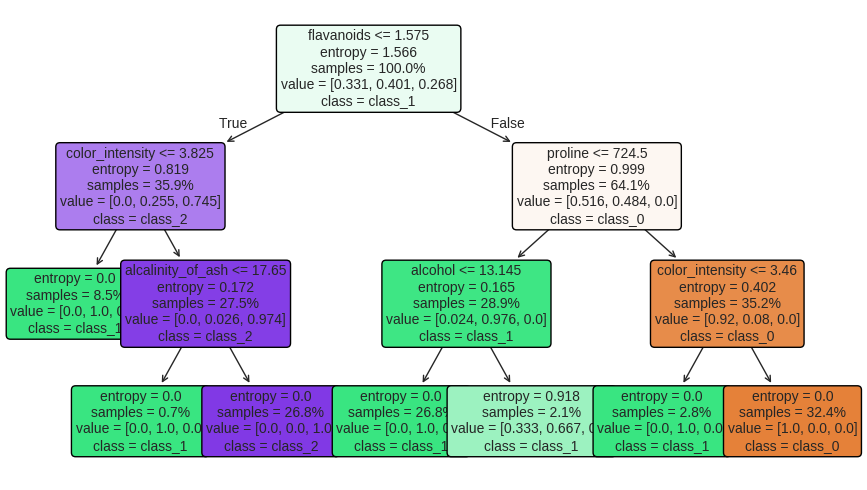

In [ ]:
# Visualize the Decision Tree

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(9, 5))

plot_tree(
    dt_model,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)

plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Make Predictions

# Predict class labels
y_pred_dt = dt_model.predict(X_test)

# Display first 10 predictions
dt_prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})

dt_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,2,1
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,2,2


In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")

Accuracy : 0.9722


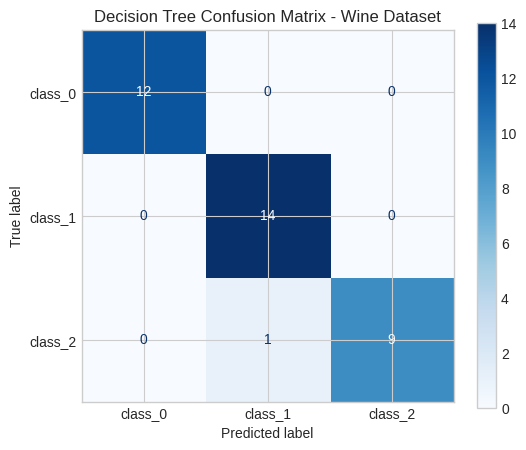

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Decision Tree Confusion Matrix - Wine Dataset")
plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



,Feature,Importance
6,flavanoids,0.408144
12,proline,0.291678
9,color_intensity,0.251272
3,alcalinity_of_ash,0.030560
0,alcohol,0.018345
4,magnesium,0.000000
2,ash,0.000000
1,malic_acid,0.000000
5,total_phenols,0.000000
8,proanthocyanins,0.000000


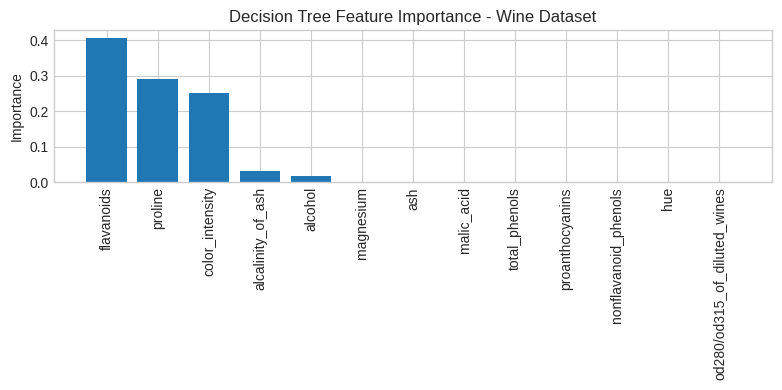

In [ ]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance

importance = pd.DataFrame({
    "Feature": wine.feature_names,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8, 4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance - Wine Dataset")
plt.tight_layout()
plt.show()

### **k-Nearest Neighbors (KNN)**

The **k-Nearest Neighbors (KNN)** algorithm is a supervised, instance-based learning method used for classification and regression. Unlike many machine learning algorithms, KNN does not build an explicit model during training. Instead, it stores the training data and predicts the class of a new sample by examining its **k closest neighbors**.

The similarity between samples is usually measured using **Euclidean distance**, although other distance metrics such as Manhattan and Minkowski distances may also be used. The predicted class is determined by majority voting among the nearest neighbors.

The most commonly used distance metric is the **Euclidean Distance**, defined as

$$
d(\mathbf{x},\mathbf{y})
=
\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

where

- $x_i$ = feature value of the query sample
- $y_i$ = feature value of the training sample
- $n$ = number of features

Another commonly used metric is the **Manhattan Distance**.

$$
d(\mathbf{x},\mathbf{y})
=
\sum_{i=1}^{n}|x_i-y_i|
$$

<p align="center">
    <img src="https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/assets/knn.gif?raw=1" width="500">
</p>

<p align="center">
<b>Figure 4.2.</b> KNN Decision Boundary
</p>

#### Advantages
- Simple and intuitive.
- No explicit training phase.
- Effective for small datasets.

#### Limitations
- Computationally expensive for large datasets.
- Sensitive to the choice of *k*.
- Performance decreases with high-dimensional data.

In [ ]:
# Train K-Nearest Neighbors (KNN) Classifier

from sklearn.neighbors import KNeighborsClassifier

# Initialize the classifier
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski",
    p=2      # Euclidean Distance
)

# Train the model
knn_model.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [ ]:
# Display Model Information

print("Number of Neighbors (K):", knn_model.n_neighbors)
print("Distance Metric        :", knn_model.metric)
print("Power Parameter (p)    :", knn_model.p)

Number of Neighbors (K): 5
Distance Metric        : minkowski
Power Parameter (p)    : 2


In [ ]:
# Make Predictions

# Predict class labels
y_pred_knn = knn_model.predict(X_test)

# Display first 10 predictions
knn_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_knn
})

knn_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy : {knn_accuracy:.4f}")

KNN Accuracy : 0.9123


#### Student Activity

Complete the following tasks by adding the necessary code cells:


- Compute the confusion matrix and visualize using a heatmap.

- Compute and display the classification report.

- Interpret the performance of the classifier based on the obtained results.

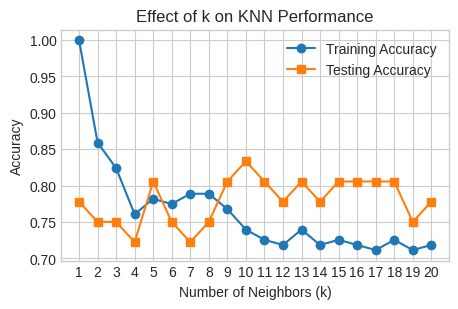

In [ ]:
# Effect of Choosing K

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
train_accuracy = []
test_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(X_train, y_train)

    # Training accuracy
    train_pred = knn.predict(X_train)
    train_accuracy.append(accuracy_score(y_train, train_pred))

    # Testing accuracy
    test_pred = knn.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, test_pred))


# Plotting the results

plt.figure(figsize=(5,3))

plt.plot(
    k_values,
    train_accuracy,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_values,
    test_accuracy,
    marker='s',
    label='Testing Accuracy'
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Effect of k on KNN Performance")
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Decsion Tree Confusion Matrix - Wine Dataset")
plt.show()

### **Naïve Bayes**

**Naïve Bayes** is a probabilistic supervised learning algorithm based on **Bayes' Theorem**. It assumes that all features are conditionally independent given the class label, which simplifies probability computation and makes the algorithm computationally efficient.

The probability of a class is calculated as:

$$
P(C|X)=\frac{P(X|C)\times P(C)}{P(X)}
$$

where:
- **P(C|X)** is the posterior probability.
- **P(X|C)** is the likelihood.
- **P(C)** is the prior probability.
- **P(X)** is the evidence.

Despite its strong independence assumption, Naïve Bayes often performs well for many real-world classification problems.

<p align="center">
    <img src="https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/assets/naive_bayes.gif?raw=1" width="500">
</p>

<p align="center">
<b>Figure 4.3.</b> Naïve Bayes Illustration
</p>

#### Advantages
- Fast training and prediction.
- Performs well with high-dimensional data.
- Works effectively with small datasets.

#### Limitations
- Assumes feature independence.
- Performance decreases when features are highly correlated.

In [ ]:
# Train Gaussian Naïve Bayes Classifier

from sklearn.naive_bayes import GaussianNB

# Initialize the classifier
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Gaussian Naïve Bayes model trained successfully!")

Gaussian Naïve Bayes model trained successfully!


In [ ]:
# Display Model Information

print("Model Type:", type(nb_model).__name__)
print("Class Prior Probabilities:")
print(nb_model.class_prior_)

Model Type: GaussianNB
Class Prior Probabilities:
[0.33098592 0.40140845 0.26760563]


In [ ]:
# Make Predictions

# Predict class labels
y_pred_nb = nb_model.predict(X_test)

# Display first 10 predictions
nb_prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_nb
})

nb_prediction_df.head(5)

,Actual,Predicted
0,0,0
1,2,2
2,0,0
3,1,1
4,1,1


In [ ]:
nv_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naïve Bayes Accuracy : {nv_accuracy:.4f}")

Gaussian Naïve Bayes Accuracy : 0.9722


#### Student Activity

Complete the following tasks by adding the necessary code cells:


- Compute the confusion matrix and visualize using a heatmap.

- Compute and display the classification report.

- Interpret the performance of the classifier based on the obtained results.

In [ ]:
# Learned Parameters

import pandas as pd

mean_df = pd.DataFrame(
    nb_model.theta_,
    columns=wine.feature_names,
    index=wine.target_names
)

display(mean_df)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,13.701489,2.063404,2.457021,17.146809,106.382979,2.821489,2.931064,0.295957,1.878298,5.478511,1.047021,3.135957,1092.340426
class_1,12.277368,1.914386,2.235965,20.428070,94.438596,2.219474,2.011404,0.357193,1.675965,2.982982,1.050105,2.767895,526.245614
class_2,13.109737,3.320526,2.444211,21.486842,99.078947,1.677632,0.776579,0.443947,1.142632,7.395000,0.676053,1.708421,622.894737


### **Support Vector Machine (SVM)**

A **Support Vector Machine (SVM)** is a supervised machine learning algorithm used primarily for classification tasks. The main objective of SVM is to find the **optimal hyperplane** that maximizes the margin between different classes.

The data points closest to the hyperplane are called **support vectors**, and they determine the position of the decision boundary. When the data are not linearly separable, SVM uses the **kernel trick** to project the data into a higher-dimensional feature space where a linear separator can be found.

Common kernel functions include:

| Kernel | Formula | Usage |
|---------|---------|-------|
| Linear | $K(x,y)=x^Ty$ | Linearly separable data |
| Polynomial | $K(x,y)=(x^Ty+c)^d$ | Nonlinear relationships |
| RBF (Gaussian) | $K(x,y)=e^{-\gamma \lVert x-y \rVert^2}$ | Most widely used |
| Sigmoid | $K(x,y)=\tanh(\alpha x^Ty+c)$ | Neural network-like behavior |

<p align="center">
    <img src="https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/assets/svm.gif?raw=1" width="500">
</p>

<p align="center">
<b>Figure 4.4.</b> SVM Illustration
</p>

For a binary classification problem, the decision boundary is represented by

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

where

- $\mathbf{w}$ = weight vector
- $\mathbf{x}$ = feature vector
- $b$ = bias term

A sample is classified according to

$$
f(\mathbf{x})=
\operatorname{sign}
(\mathbf{w}^T\mathbf{x}+b)
$$

where

- $f(\mathbf{x})=+1$ → Class 1
- $f(\mathbf{x})=-1$ → Class 2

The margin is the perpendicular distance between the two supporting hyperplanes.

$$
Margin=
\frac{2}{||\mathbf{w}||}
$$

A larger margin generally leads to better generalization.

The optimization problem is

$$
\min
\frac{1}{2}
||\mathbf{w}||^2
$$

subject to

$$
y_i(\mathbf{w}^T\mathbf{x_i}+b)\ge1
$$

where

- $y_i$ = class label
- $\mathbf{x_i}$ = training sample

#### Advantages
- Effective for high-dimensional datasets.
- Works well with small and medium-sized datasets.
- Robust against overfitting.

#### Limitations
- Computationally expensive for very large datasets.
- Choosing an appropriate kernel and parameters can be challenging.
- Less interpretable than decision trees.

In [ ]:
# Train Support Vector Machine (SVM) Classifier

from sklearn.svm import SVC

# Initialize the classifier
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

# Train the model
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully!")

Support Vector Machine model trained successfully!


In [ ]:
# Display Model Information

print("Kernel          :", svm_model.kernel)
print("Penalty (C)     :", svm_model.C)
print("Gamma           :", svm_model.gamma)
print("Support Vectors :", svm_model.n_support_)

Kernel          : rbf
Penalty (C)     : 1.0
Gamma           : scale
Support Vectors : [63 61]


In [ ]:
# Make Predictions

# Predict class labels
y_pred_svm = svm_model.predict(X_test)

# Display first 10 predictions
svm_prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

svm_prediction_df.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,1
3,1,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Machine Accuracy : {svm_accuracy:.4f}")

Support Vector Machine Accuracy : 0.9298


#### Student Activity

Complete the following tasks by adding the necessary code cells:


- Compute the confusion matrix and visualize using a heatmap.

- Compute and display the classification report.

- Interpret the performance of the classifier based on the obtained results.

    Kernel  Training Accuracy  Testing Accuracy
0   linear           0.958242          0.956140
1     poly           0.909890          0.921053
2      rbf           0.918681          0.929825
3  sigmoid           0.461538          0.447368


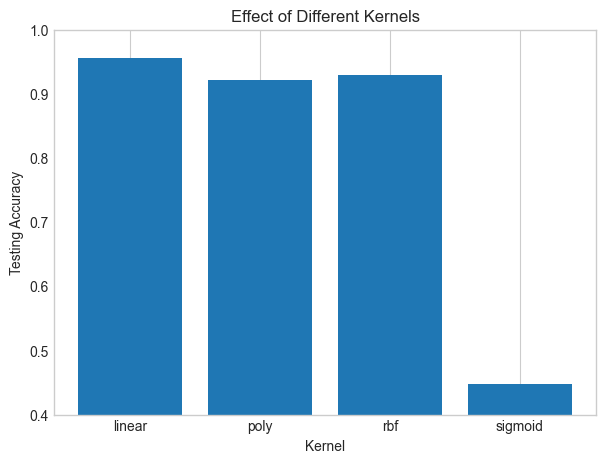

In [ ]:
# Effect of Different Kernels

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

kernels = ["linear", "poly", "rbf", "sigmoid"]

results = []

for kernel in kernels:

    model = SVC(
        kernel=kernel,
        probability=True,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append([
        kernel,
        train_acc,
        test_acc
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Kernel",
        "Training Accuracy",
        "Testing Accuracy"
    ]
)

print(results)


# Visualize the Effect of Different Kernels

plt.figure(figsize=(7,5))

plt.bar(
    results["Kernel"],
    results["Testing Accuracy"]
)

plt.ylabel("Testing Accuracy")
plt.xlabel("Kernel")
plt.title("Effect of Different Kernels")
plt.ylim(0.4, 1.0)
plt.grid(axis="y")
plt.show()

### **Comparison**

In [1]:
# Compare All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
from sklearn.preprocessing import label_binarize

models = {
    "Decision Tree": (dt_model, y_pred_dt),
    "KNN": (knn_model, y_pred_knn),
    "Naïve Bayes": (nb_model, y_pred_nb),
    "SVM": (svm_model, y_pred_svm)
}

comparison = []

for name, (model, y_pred) in models.items():

    auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    comparison.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted"),
        auc_score
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ]
)

comparison_df = comparison_df.round(4)

comparison_df

NameError: name 'dt_model' is not defined

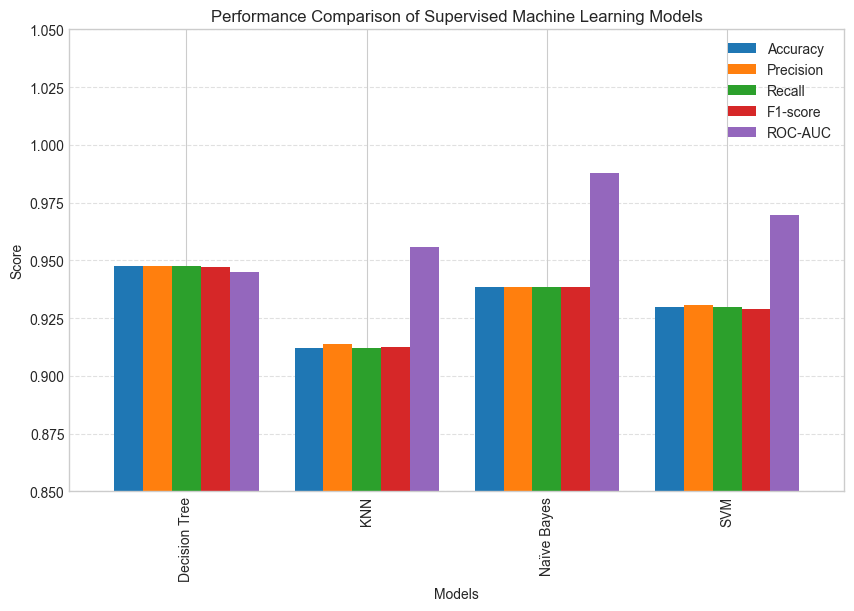

In [ ]:
# Grouped Bar Chart of Performance Metrics

import matplotlib.pyplot as plt

comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Performance Comparison of Supervised Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0.85, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(loc="upper right")
plt.show()

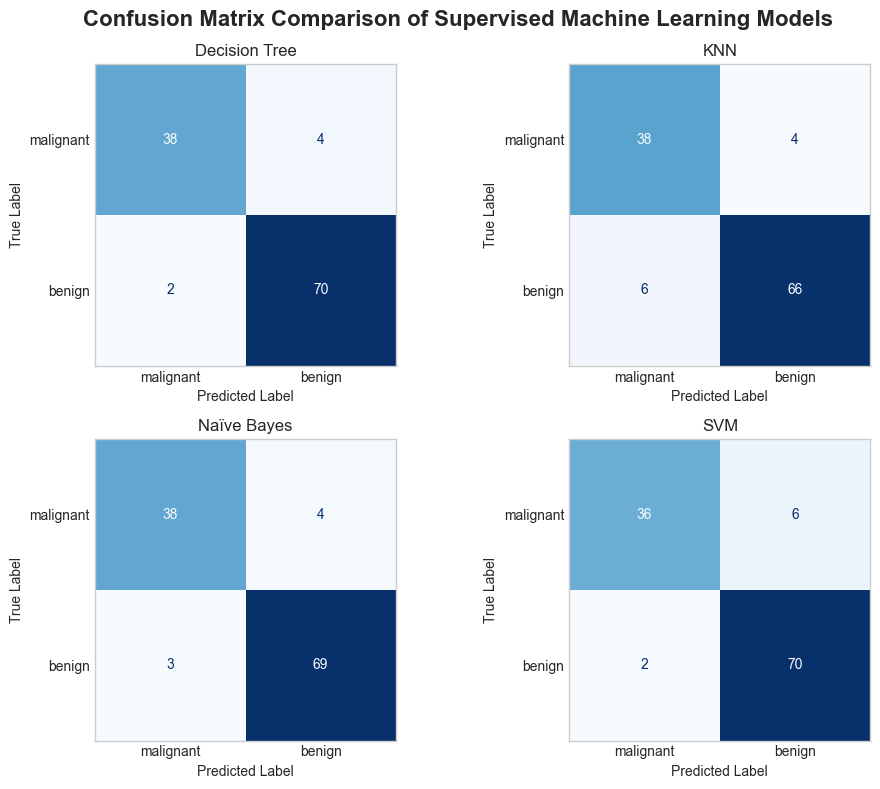

In [ ]:
# Confusion Matrix Comparison

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Model names and predictions
models = {
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "Naïve Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, models.items()):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data.target_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.grid(False)

plt.suptitle(
    "Confusion Matrix Comparison of Supervised Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## **Expected Output**

After running all cells, the notebook should display:

- Dataset shape, class counts, and target names.
- Train/test split shapes.
- A metric comparison table (accuracy, precision, recall, F1-score, ROC-AUC) for all four models.
- A detailed classification report for the best-performing model.
- Confusion matrices for all four models in a 2x2 grid.
- ROC curves for all four models on a single plot.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Discussion**

Decision trees are easy to interpret and often perform well, but they may overfit. KNN is intuitive but depends on local neighborhoods and feature scaling. Naive Bayes is computationally efficient but relies on independence assumptions. SVM often gives strong performance when the classes are well separated in a transformed feature space.

## **Viva Questions**

1. **Q:** Why is train/test splitting important?  
   **A:** It provides an unbiased estimate of how the model will perform on unseen data.

2. **Q:** Why do KNN and SVM usually need feature scaling?  
   **A:** Because they depend on distances or margins that are sensitive to feature magnitude.

3. **Q:** What does ROC-AUC measure?  
   **A:** It measures how well the model separates the two classes across all classification thresholds.

4. **Q:** What is the advantage of a decision tree?  
   **A:** It is interpretable and easy to explain.

5. **Q:** Why is Naive Bayes called naive?  
   **A:** Because it assumes conditional independence among features.

6. **Q:** What does a confusion matrix show?  
   **A:** The counts of true positives, false positives, true negatives, and false negatives.

7. **Q:** What is the margin in SVM?  
   **A:** The distance between the separating hyperplane and the nearest training points.

8. **Q:** What is overfitting?  
   **A:** When a model fits training data too closely and performs poorly on new data.

9. **Q:** Why is the Breast Cancer dataset suitable for comparison?  
   **A:** It is a realistic binary classification benchmark with numerical features.

10. **Q:** Why is F1-score useful?  
    **A:** It balances precision and recall in one metric.

## **Exercises**

Complete the following tasks after running the notebook:

1. Tune the number of neighbors in KNN and observe the effect on accuracy.
2. Change the SVM kernel (e.g. `linear`, `poly`) and compare the results.
3. Prune the decision tree (e.g. set `max_depth`) and evaluate whether test performance improves.
4. Implement cross-validation for all four models and compare mean scores.
5. Add logistic regression as a fifth model and include it in the comparison table.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including the metric comparison table.
- Confusion matrices and ROC curves for all four models.
- Short discussion of which model performed best and why.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
